<a href="https://colab.research.google.com/github/Divyam-Deep/ecommerce-sales-analysis/blob/main/the_divyam_deep_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ============================================================
# E-COMMERCE COMPANY'S PATH TO SUSTAINABLE GROWTH
# Complete Analysis | Mentor-Reviewed Final Version
# ============================================================

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
sns.set_palette("husl")

# ============================================================
# STEP 1: DATA EXPLORATION & UNDERSTANDING
# ============================================================

In [81]:
print("=" * 80)
print("STEP 1: DATA EXPLORATION & UNDERSTANDING")
print("=" * 80)

df = pd.read_csv('sales_dataset.csv', low_memory=False)

print(f"\nDataset Shape: {df.shape}")
print(f"\nFirst 5 Rows:")
print(df.head())

print(f"\nData Types & Info:")
df.info()

print(f"\nStatistical Summary:")
print(df.describe())

print(f"\nMissing Values per Column:")
print(df.isnull().sum())


STEP 1: DATA EXPLORATION & UNDERSTANDING

Dataset Shape: (128949, 23)

First 5 Rows:
              Order ID      Date                        Status Fulfilment  \
0  405-8078784-5731545  04-30-22                     Cancelled   Merchant   
1  171-9198151-1101146  04-30-22  Shipped - Delivered to Buyer   Merchant   
2  404-0687676-7273146  04-30-22                       Shipped     Amazon   
3  403-9615377-8133951  04-30-22                     Cancelled   Merchant   
4  407-1069790-7240320  04-30-22                       Shipped     Amazon   

  Sales Channel  ship-service-level    Style              SKU       Category  \
0      Amazon.in           Standard   SET389   SET389-KR-NP-S            Set   
1      Amazon.in           Standard  JNE3781  JNE3781-KR-XXXL          kurta   
2      Amazon.in          Expedited  JNE3371    JNE3371-KR-XL          kurta   
3      Amazon.in           Standard    J0341       J0341-DR-L  Western Dress   
4      Amazon.in          Expedited  JNE3671  JNE367

# ============================================================
# STEP 2: DATA CLEANING  
# (Mentor Rule: ONE copy only — df1. No multiple copies.)
# ============================================================

In [82]:
print("\n" + "=" * 80)
print("STEP 2: DATA CLEANING")
print("=" * 80)

# Check duplicates before making the copy
print(f"Duplicate rows in raw data: {df.duplicated().sum()}")
df_deduped = df.drop_duplicates()
print(f"Rows after deduplication: {df_deduped.shape[0]}")

# Single copy — all cleaning done on df1
df1 = df_deduped.drop('Unnamed: 22', axis=1, errors='ignore')



STEP 2: DATA CLEANING
Duplicate rows in raw data: 6
Rows after deduplication: 128943


In [83]:
# --- Mentor Rule: Amount column ---
# Step 1: Set Amount = 0 where Status is Cancelled (data correction)
# Step 2: Compute median on corrected data
# Step 3: Fill NaN with that median
print(f"\nAmount null count before cleaning: {df1['Amount'].isnull().sum()}")
df1.loc[df1['Status'] == 'Cancelled', 'Amount'] = 0
print(f"Set Amount = 0 for all Cancelled orders.")
median_amount = df1['Amount'].median()
print(f"Median Amount (after zeroing cancelled): ₹{median_amount:.2f}")
df1['Amount'] = df1['Amount'].fillna(median_amount)
print(f"Filled NaN values with median. Remaining nulls: {df1['Amount'].isnull().sum()}")



Amount null count before cleaning: 7791
Set Amount = 0 for all Cancelled orders.
Median Amount (after zeroing cancelled): ₹545.00
Filled NaN values with median. Remaining nulls: 0


In [84]:
# Convert Date to datetime
df1['Date'] = pd.to_datetime(df1['Date'], format='mixed', errors='coerce')

# Extract time features
df1['Year']      = df1['Date'].dt.year
df1['Month']     = df1['Date'].dt.month
df1['Day']       = df1['Date'].dt.day
df1['MonthName'] = df1['Date'].dt.month_name()
df1['DayName']   = df1['Date'].dt.day_name()
df1['Quarter']   = df1['Date'].dt.quarter
df1['Week']      = df1['Date'].dt.isocalendar().week

In [85]:
# ship location columns: very small null count in 1L rows → drop those rows
df1.dropna(subset=['ship-city', 'ship-state', 'ship-postal-code', 'ship-country'], inplace=True)

In [86]:
# Courier Status: no impact on business → fill with 'Not Available'
df1['Courier Status'] = df1['Courier Status'].fillna('Not Available')

In [87]:
# Currency: only INR exists → fill nulls with 'INR'
print(f"\nUnique currency values: {df1['currency'].unique()}")
df1['currency'] = df1['currency'].fillna('INR')


Unique currency values: ['INR' nan]


In [88]:
# Promotion IDs: null means no promotion applied
df1['promotion-ids'] = df1['promotion-ids'].fillna('No Promotion')

In [89]:
# Fulfilled-by: Amazon filled always; merchant side often missed
df1['fulfilled-by'] = df1['fulfilled-by'].fillna('Merchant')

In [90]:
# Sort by date
df1.sort_values('Date', inplace=True)
df1.reset_index(drop=True, inplace=True)

In [91]:
print(f"\nFinal df1 shape: {df1.shape}")
print(f"Remaining null values: {df1.isnull().sum().sum()}")
print(f"\ndf1 after cleaning (first 5 rows):")
print(df1.head())


Final df1 shape: (128910, 29)
Remaining null values: 0

df1 after cleaning (first 5 rows):
              Order ID       Date                        Status Fulfilment  \
0  404-1445673-1345134 2022-03-31  Shipped - Delivered to Buyer   Merchant   
1  406-7387241-2881923 2022-03-31                       Shipped     Amazon   
2  402-9332104-0945115 2022-03-31                     Cancelled   Merchant   
3  408-1008226-2450750 2022-03-31                       Shipped     Amazon   
4  403-4108307-0229121 2022-03-31                       Shipped     Amazon   

  Sales Channel  ship-service-level    Style              SKU Category Size  \
0      Amazon.in           Standard  JNE3724     JNE3724-KR-L    kurta    L   
1      Amazon.in          Expedited   SET187  SET187-KR-DH-XL      Set   XL   
2      Amazon.in           Standard  JNE3383   JNE3383-KR-A-M    kurta    M   
3      Amazon.in          Expedited  JNE3405     JNE3405-KR-L    kurta    L   
4      Amazon.in          Expedited   SET044

In [92]:
# Helper flags — added directly to df1
cancel_statuses = [
    'Cancelled',
    'Shipped - Returned to Seller',
    'Shipped - Returning to Seller',
    'Shipped - Rejected by Buyer',
    'Shipped - Lost in Transit',
    'Shipped - Damaged'
]
df1['is_cancelled']       = df1['Status'].isin(cancel_statuses)
df1['customer_cancelled'] = df1['Status'].isin(['Cancelled', 'Shipped - Rejected by Buyer'])
df1['logistics_failed']   = df1['Status'].isin([
    'Shipped - Returned to Seller',
    'Shipped - Returning to Seller',
    'Shipped - Lost in Transit',
    'Shipped - Damaged'
])
df1['promo_flag'] = np.where(
    df1['promotion-ids'] == 'No Promotion', 'No Promotion', 'Promotion'
)

# ============================================================
# ANALYSIS 1: FINANCIAL PERFORMANCE
# ============================================================


In [93]:
print("\n" + "=" * 80)
print("ANALYSIS 1: FINANCIAL PERFORMANCE")
print("=" * 80)

total_revenue   = df1['Amount'].sum()
total_orders    = len(df1)
avg_order_value = df1['Amount'].mean()

print(f"\nTotal Revenue       : ₹{total_revenue:,.2f}")
print(f"Total Orders        : {total_orders:,}")
print(f"Average Order Value : ₹{avg_order_value:.2f}")
print(f"Median Order Value  : ₹{df1['Amount'].median():.2f}")
print(f"Std Dev             : ₹{df1['Amount'].std():.2f}")
print(f"Min Order           : ₹{df1['Amount'].min():.2f}")
print(f"Max Order           : ₹{df1['Amount'].max():.2f}")


ANALYSIS 1: FINANCIAL PERFORMANCE

Total Revenue       : ₹71,755,672.62
Total Orders        : 128,910
Average Order Value : ₹556.63
Median Order Value  : ₹545.00
Std Dev             : ₹346.49
Min Order           : ₹0.00
Max Order           : ₹5584.00


In [94]:
# Monthly Revenue with MoM Growth
monthly_revenue = df1.groupby(['Year', 'Month', 'MonthName']).agg(
    Revenue=('Amount', 'sum'),
    Orders=('Order ID', 'count'),
    Total_Qty=('Qty', 'sum')
).reset_index().sort_values(['Year', 'Month'])
monthly_revenue['MoM_Growth_%'] = monthly_revenue['Revenue'].pct_change() * 100

print("\nMonthly Revenue with MoM Growth:")
for _, row in monthly_revenue.iterrows():
    growth = f"  (MoM: {row['MoM_Growth_%']:+.2f}%)" if pd.notna(row['MoM_Growth_%']) else ""
    print(f"  {row['MonthName']} {int(row['Year'])}: ₹{row['Revenue']:,.2f} | {int(row['Orders'])} orders{growth}")


Monthly Revenue with MoM Growth:
  March 2022: ₹95,355.00 | 171 orders
  April 2022: ₹26,272,649.62 | 49043 orders  (MoM: +27452.46%)
  May 2022: ₹23,975,445.00 | 42020 orders  (MoM: -8.74%)
  June 2022: ₹21,412,223.00 | 37676 orders  (MoM: -10.69%)


In [95]:
# Seasonal trends
print("\nSeasonal Sales Trends (by Month):")
seasonal_sales = df1.groupby('MonthName')['Amount'].agg(['sum', 'mean', 'count'])
seasonal_sales.columns = ['Total_Revenue', 'Avg_Order_Value', 'Orders']
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
seasonal_sales = seasonal_sales.reindex([m for m in month_order if m in seasonal_sales.index])
print(seasonal_sales)


Seasonal Sales Trends (by Month):
           Total_Revenue  Avg_Order_Value  Orders
MonthName                                        
March           95355.00       557.631579     171
April        26272649.62       535.706413   49043
May          23975445.00       570.572228   42020
June         21412223.00       568.325273   37676


In [96]:
# Daily Revenue Trend
print("Daily Revenue (first 10 days):")
daily_revenue = df1.groupby('Date')['Amount'].sum().reset_index()
daily_revenue.columns = ['Date', 'Revenue']
print(daily_revenue.head(10))


Daily Revenue (first 10 days):
        Date   Revenue
0 2022-03-31   95355.0
1 2022-04-01  782462.0
2 2022-04-02  812745.0
3 2022-04-03  925594.0
4 2022-04-04  814253.0
5 2022-04-05  880784.0
6 2022-04-06  818278.0
7 2022-04-07  814016.0
8 2022-04-08  923159.0
9 2022-04-09  879018.0


In [97]:
# Monthly AOV Trend
print("Monthly Average Order Value (AOV) Trend:")
monthly_aov = df1.groupby(['Year', 'Month', 'MonthName'])['Amount'].mean().reset_index()
monthly_aov.columns = ['Year', 'Month', 'MonthName', 'AOV']
monthly_aov = monthly_aov.sort_values(['Year', 'Month'])
for _, row in monthly_aov.iterrows():
    print(f"  {row['MonthName']} {int(row['Year'])}: AOV = ₹{row['AOV']:.2f}")


Monthly Average Order Value (AOV) Trend:
  March 2022: AOV = ₹557.63
  April 2022: AOV = ₹535.71
  May 2022: AOV = ₹570.57
  June 2022: AOV = ₹568.33


In [98]:
# Category-wise AOV
print("Category-wise AOV:")
cat_aov = df1.groupby('Category')['Amount'].mean().sort_values(ascending=False).head(10)
print(cat_aov)

Category-wise AOV:
Category
Set              711.670058
Saree            699.353659
Western Dress    658.814380
Ethnic Dress     632.177029
Top              462.184010
Blouse           454.178186
kurta            390.548820
Bottom           309.086364
Dupatta          305.000000
Name: Amount, dtype: float64


In [99]:
# --- Mentor Point 4: Weekly trend by weekday (after monthly chart) ---
print("\nWeekly Trend by Day of Week:")
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekly_trend = df1.groupby('DayName').agg(
    Revenue=('Amount', 'sum'),
    Orders=('Order ID', 'count'),
    Avg_Order_Value=('Amount', 'mean')
)
weekly_trend = weekly_trend.reindex([d for d in day_order if d in weekly_trend.index])
print(weekly_trend)


Weekly Trend by Day of Week:
               Revenue  Orders  Avg_Order_Value
DayName                                        
Monday     10301063.00   18559       555.044076
Tuesday    10487472.00   18872       555.715981
Wednesday  10311378.00   18581       554.942038
Thursday    9489732.00   17066       556.060705
Friday      9859181.00   17709       556.732791
Saturday   10297316.62   18505       556.461314
Sunday     11009530.00   19618       561.195331


In [100]:
# Best-selling categories
print("\nTop 10 Product Categories by Revenue:")
top_categories = df1.groupby('Category').agg(
    Revenue=('Amount', 'sum'),
    Units_Sold=('Qty', 'sum'),
    Orders=('Order ID', 'count')
).sort_values('Revenue', ascending=False).head(10)
print(top_categories)


Top 10 Product Categories by Revenue:
                   Revenue  Units_Sold  Orders
Category                                      
Set            35768537.14       45275   50260
kurta          19467296.48       45034   49846
Western Dress  10207670.00       13942   15494
Top             4907932.00        9900   10619
Ethnic Dress     732061.00        1052    1158
Blouse           420569.00         864     926
Bottom           135998.00         398     440
Saree            114694.00         152     164
Dupatta             915.00           3       3


In [101]:
# AOV by segment
print("\nAverage Order Value — B2B vs B2C:")
print(df1.groupby('B2B')['Amount'].mean().rename({False: 'B2C', True: 'B2B'}))


Average Order Value — B2B vs B2C:
B2B
B2C    556.047201
B2B    642.876005
Name: Amount, dtype: float64


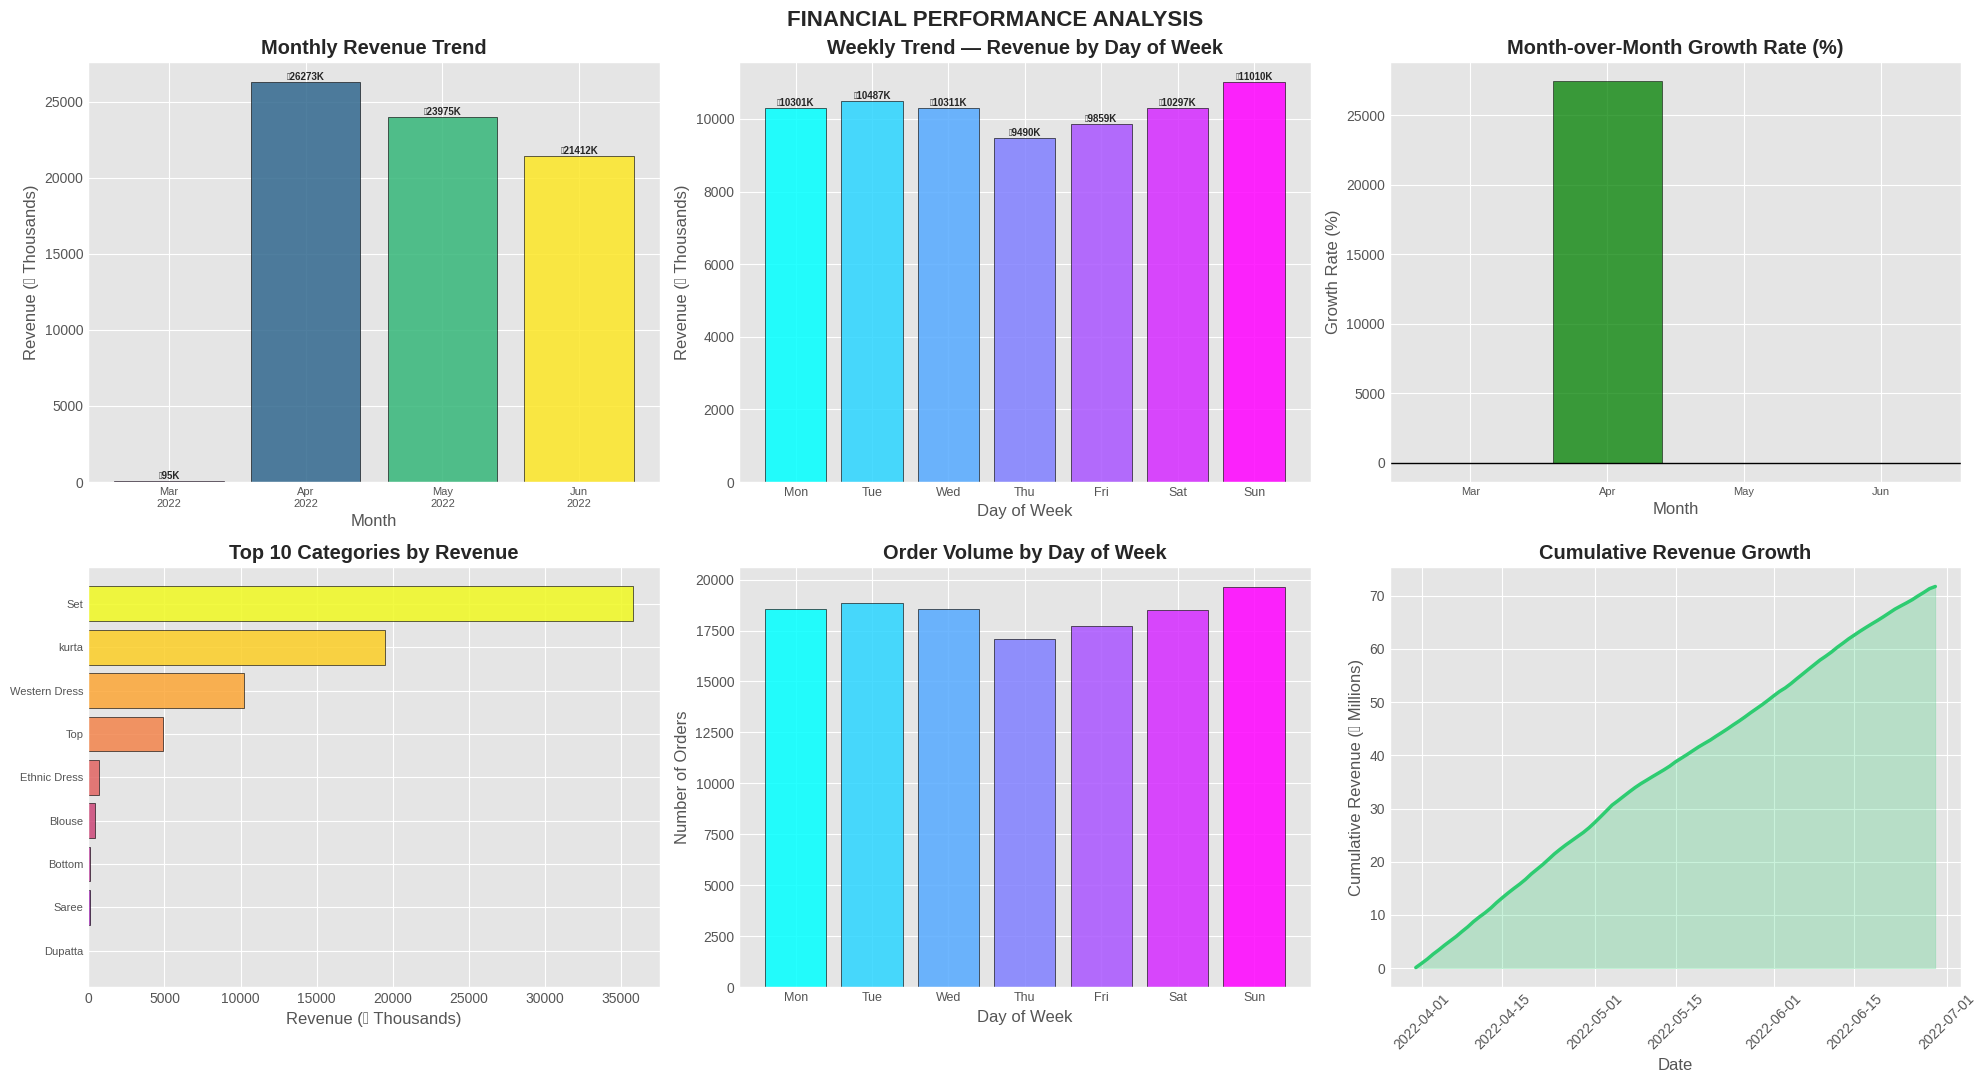

Chart saved: analysis_1_financial_performance.png


In [102]:
# --- VISUALIZATIONS: Financial Performance ---
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
fig.suptitle('FINANCIAL PERFORMANCE ANALYSIS', fontsize=16, fontweight='bold')


# 1. Monthly Revenue Trend
ax = axes[0, 0]
x_pos = range(len(monthly_revenue))
colors_m = plt.cm.viridis(np.linspace(0, 1, len(monthly_revenue)))
bars = ax.bar(x_pos, monthly_revenue['Revenue'] / 1000, color=colors_m, alpha=0.85, edgecolor='black')
ax.set_title('Monthly Revenue Trend', fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (₹ Thousands)')
ax.set_xticks(list(x_pos))
ax.set_xticklabels(
    [f"{r['MonthName'][:3]}\n{int(r['Year'])}" for _, r in monthly_revenue.iterrows()],
    fontsize=8
)
for bar, val in zip(bars, monthly_revenue['Revenue']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'₹{val/1000:.0f}K', ha='center', va='bottom', fontsize=7, fontweight='bold')

 # 2. Weekly Trend by Day of Week  ← Mentor Point 4
ax = axes[0, 1]
colors_w = plt.cm.cool(np.linspace(0, 1, len(weekly_trend)))
bars_w = ax.bar(range(len(weekly_trend)), weekly_trend['Revenue'] / 1000,
                color=colors_w, alpha=0.85, edgecolor='black')
ax.set_title('Weekly Trend — Revenue by Day of Week', fontweight='bold')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Revenue (₹ Thousands)')
ax.set_xticks(range(len(weekly_trend)))
ax.set_xticklabels([d[:3] for d in weekly_trend.index], fontsize=9)
for bar in bars_w:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'₹{bar.get_height():.0f}K', ha='center', va='bottom', fontsize=7, fontweight='bold')


# 3. MoM Growth Rate
ax = axes[0, 2]
mom_colors = ['green' if x > 0 else 'red' for x in monthly_revenue['MoM_Growth_%'].fillna(0)]
ax.bar(range(len(monthly_revenue)), monthly_revenue['MoM_Growth_%'].fillna(0),
       color=mom_colors, alpha=0.75, edgecolor='black')
ax.axhline(y=0, color='black', linewidth=1)
ax.set_title('Month-over-Month Growth Rate (%)', fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Growth Rate (%)')
ax.set_xticks(range(len(monthly_revenue)))
ax.set_xticklabels([f"{r['MonthName'][:3]}" for _, r in monthly_revenue.iterrows()], fontsize=8)

# 4. Top Product Categories by Revenue
ax = axes[1, 0]
top_cats = df1.groupby('Category')['Amount'].sum().sort_values(ascending=True).tail(10)
colors_c = plt.cm.plasma(np.linspace(0.2, 1, len(top_cats)))
ax.barh(range(len(top_cats)), top_cats.values / 1000, color=colors_c, alpha=0.85, edgecolor='black')
ax.set_yticks(range(len(top_cats)))
ax.set_yticklabels(top_cats.index, fontsize=8)
ax.set_title('Top 10 Categories by Revenue', fontweight='bold')
ax.set_xlabel('Revenue (₹ Thousands)')

# 5. Orders by Day of Week
ax = axes[1, 1]
ax.bar(range(len(weekly_trend)), weekly_trend['Orders'],
       color=colors_w, alpha=0.85, edgecolor='black')
ax.set_title('Order Volume by Day of Week', fontweight='bold')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Number of Orders')
ax.set_xticks(range(len(weekly_trend)))
ax.set_xticklabels([d[:3] for d in weekly_trend.index], fontsize=9)

# 6. Cumulative Revenue Growth
ax = axes[1, 2]
daily_rev_cum = df1.groupby('Date')['Amount'].sum().cumsum()
ax.plot(daily_rev_cum.index, daily_rev_cum.values / 1e6, linewidth=2.5, color='#2ecc71')
ax.fill_between(daily_rev_cum.index, daily_rev_cum.values / 1e6, alpha=0.25, color='#2ecc71')
ax.set_title('Cumulative Revenue Growth', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Revenue (₹ Millions)')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('analysis_1_financial_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: analysis_1_financial_performance.png")




# ============================================================
# ANALYSIS 2: CUSTOMER INSIGHTS
# ============================================================

In [103]:
print("\n" + "=" * 80)
print("ANALYSIS 2: CUSTOMER INSIGHTS")
print("=" * 80)

# Top locations
print("\nTop 10 States by Revenue:")
top_states = df1.groupby('ship-state').agg(
    Revenue=('Amount', 'sum'), Orders=('Order ID', 'count')
).sort_values('Revenue', ascending=False).head(10)
for i, (state, row) in enumerate(top_states.iterrows(), 1):
    pct = (row['Revenue'] / total_revenue) * 100
    print(f"  {i}. {state}: ₹{row['Revenue']:,.2f} ({pct:.1f}%) | {int(row['Orders'])} orders")

print("\nTop 10 Cities by Revenue:")
top_cities = df1.groupby('ship-city').agg(
    Revenue=('Amount', 'sum'), Orders=('Order ID', 'count')
).sort_values('Revenue', ascending=False).head(10)
for i, (city, row) in enumerate(top_cities.iterrows(), 1):
    print(f"  {i}. {city}: ₹{row['Revenue']:,.2f} | {int(row['Orders'])} orders")


ANALYSIS 2: CUSTOMER INSIGHTS

Top 10 States by Revenue:
  1. MAHARASHTRA: ₹12,233,176.00 (17.0%) | 22256 orders
  2. KARNATAKA: ₹9,648,329.00 (13.4%) | 17320 orders
  3. TELANGANA: ₹6,293,653.57 (8.8%) | 11327 orders
  4. UTTAR PRADESH: ₹6,184,515.00 (8.6%) | 10635 orders
  5. TAMIL NADU: ₹5,958,817.00 (8.3%) | 11481 orders
  6. DELHI: ₹3,907,340.48 (5.4%) | 6780 orders
  7. KERALA: ₹3,378,602.00 (4.7%) | 6584 orders
  8. WEST BENGAL: ₹3,208,055.00 (4.5%) | 5961 orders
  9. ANDHRA PRADESH: ₹2,886,567.00 (4.0%) | 5429 orders
  10. HARYANA: ₹2,654,992.00 (3.7%) | 4413 orders

Top 10 Cities by Revenue:
  1. BENGALURU: ₹6,349,713.00 | 11211 orders
  2. HYDERABAD: ₹4,499,883.57 | 8071 orders
  3. MUMBAI: ₹3,400,494.00 | 6124 orders
  4. NEW DELHI: ₹3,331,168.48 | 5793 orders
  5. CHENNAI: ₹2,823,610.00 | 5419 orders
  6. PUNE: ₹2,153,145.00 | 3855 orders
  7. KOLKATA: ₹1,305,113.00 | 2381 orders
  8. GURUGRAM: ₹1,135,033.00 | 1867 orders
  9. THANE: ₹918,782.00 | 1701 orders
  10. LUCKNOW

In [104]:
# --- Mentor Point 5: Monthly cancellation trend + overall rate + AOV + total cancelled ---
print("\n--- CANCELLATION SUMMARY (Mentor Point 5) ---")
total_cancelled_orders = int(df1['customer_cancelled'].sum())
overall_cancel_rate    = df1['customer_cancelled'].mean() * 100
aov_cancelled          = df1[df1['customer_cancelled']]['Amount'].mean()
revenue_lost           = df1[df1['customer_cancelled']]['Amount'].sum()

print(f"  Total Cancelled Orders   : {total_cancelled_orders:,}")
print(f"  Overall Cancellation Rate: {overall_cancel_rate:.2f}%")
print(f"  AOV (Cancelled Orders)   : ₹{aov_cancelled:.2f}")
print(f"  Revenue Lost             : ₹{revenue_lost:,.2f}")


--- CANCELLATION SUMMARY (Mentor Point 5) ---
  Total Cancelled Orders   : 18,342
  Overall Cancellation Rate: 14.23%
  AOV (Cancelled Orders)   : ₹0.40
  Revenue Lost             : ₹7,295.00


In [105]:
# Monthly cancellation trend
cancel_trend = df1.groupby(df1['Date'].dt.to_period('M')).agg(
    total_orders=('Order ID', 'count'),
    cancelled_orders=('customer_cancelled', 'sum')
)
cancel_trend['cancel_rate']  = cancel_trend['cancelled_orders'] / cancel_trend['total_orders']
cancel_trend['success_rate'] = 1 - cancel_trend['cancel_rate']

print("\nMonthly Cancellation Trend:")
print(cancel_trend[['total_orders', 'cancelled_orders', 'cancel_rate']].to_string())


Monthly Cancellation Trend:
         total_orders  cancelled_orders  cancel_rate
Date                                                
2022-03           171                18     0.105263
2022-04         49043              7139     0.145566
2022-05         42020              5879     0.139910
2022-06         37676              5306     0.140832


In [106]:
# B2B vs B2C
print("\nB2B vs B2C Analysis:")
b2b_analysis = df1.groupby('B2B').agg(
    Orders=('Order ID', 'count'),
    Revenue=('Amount', 'sum'),
    Avg_Order_Value=('Amount', 'mean'),
    Cancel_Rate=('customer_cancelled', 'mean'),
    Logistics_Fail_Rate=('logistics_failed', 'mean')
)
b2b_analysis.index = ['B2C', 'B2B']
print(b2b_analysis)


B2B vs B2C Analysis:
     Orders      Revenue  Avg_Order_Value  Cancel_Rate  Logistics_Fail_Rate
B2C  128039  71195727.62       556.047201     0.142683             0.016339
B2B     871    559945.00       642.876005     0.083812             0.010333


In [107]:
# Promotion impact
print("\nRevenue by Promotion Flag:")
print(df1.groupby('promo_flag')['Amount'].sum())
print("\nCancellation Rate by Promotion:")
print(df1.groupby('promo_flag')['customer_cancelled'].mean())


Revenue by Promotion Flag:
promo_flag
No Promotion    18182499.62
Promotion       53573173.00
Name: Amount, dtype: float64

Cancellation Rate by Promotion:
promo_flag
No Promotion    0.366876
Promotion       0.003973
Name: customer_cancelled, dtype: float64


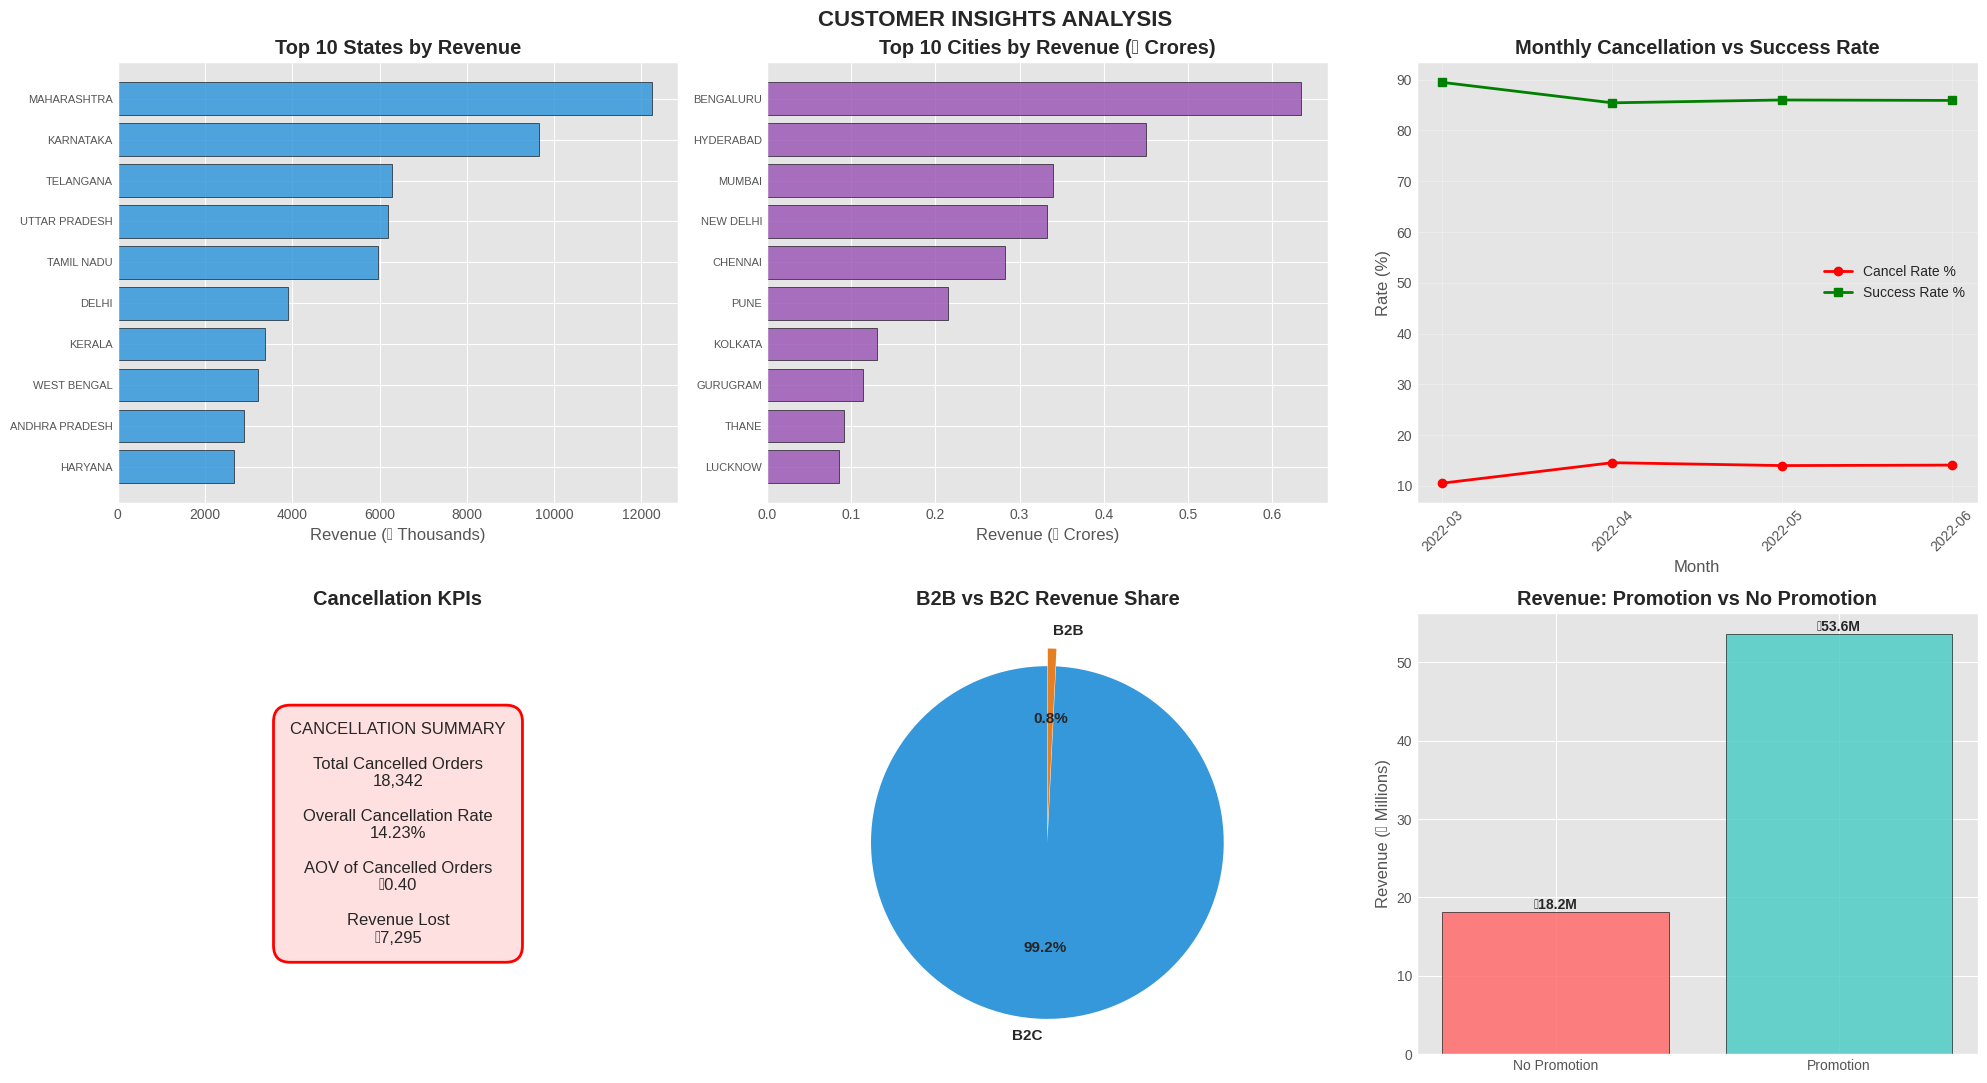

Chart saved: analysis_2_customer_insights.png


In [108]:
# --- VISUALIZATIONS: Customer Insights ---
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
fig.suptitle('CUSTOMER INSIGHTS ANALYSIS', fontsize=16, fontweight='bold')

# 1. Top 10 States
ax = axes[0, 0]
top10s = df1.groupby('ship-state')['Amount'].sum().sort_values(ascending=True).tail(10)
ax.barh(range(len(top10s)), top10s.values / 1000, color='#3498db', alpha=0.85, edgecolor='black')
ax.set_yticks(range(len(top10s)))
ax.set_yticklabels(top10s.index, fontsize=8)
ax.set_title('Top 10 States by Revenue', fontweight='bold')
ax.set_xlabel('Revenue (₹ Thousands)')

# 2. Top 10 Cities
ax = axes[0, 1]
top10c = df1.groupby('ship-city')['Amount'].sum().sort_values(ascending=True).tail(10)
ax.barh(range(len(top10c)), top10c.values / 1e7, color='#9b59b6', alpha=0.85, edgecolor='black')
ax.set_yticks(range(len(top10c)))
ax.set_yticklabels(top10c.index, fontsize=8)
ax.set_title('Top 10 Cities by Revenue (₹ Crores)', fontweight='bold')
ax.set_xlabel('Revenue (₹ Crores)')

# 3. Monthly Cancellation & Success Rate  ← Mentor Point 5
ax = axes[0, 2]
x_labels = cancel_trend.index.astype(str)
ax.plot(x_labels, cancel_trend['cancel_rate'] * 100,  marker='o', color='red',   label='Cancel Rate %', linewidth=2)
ax.plot(x_labels, cancel_trend['success_rate'] * 100, marker='s', color='green', label='Success Rate %', linewidth=2)
ax.set_title('Monthly Cancellation vs Success Rate', fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Rate (%)')
ax.tick_params(axis='x', rotation=45)
ax.legend()
ax.grid(alpha=0.3)

# 4. Cancellation KPI summary  ← Mentor Point 5
ax = axes[1, 0]
ax.axis('off')
kpi_text = (
    f"CANCELLATION SUMMARY\n\n"
    f"Total Cancelled Orders\n{total_cancelled_orders:,}\n\n"
    f"Overall Cancellation Rate\n{overall_cancel_rate:.2f}%\n\n"
    f"AOV of Cancelled Orders\n₹{aov_cancelled:.2f}\n\n"
    f"Revenue Lost\n₹{revenue_lost:,.0f}"
)
ax.text(0.5, 0.5, kpi_text, transform=ax.transAxes, fontsize=12,
        ha='center', va='center',
        bbox=dict(boxstyle='round,pad=1', facecolor='#ffe0e0', edgecolor='red', linewidth=2))
ax.set_title('Cancellation KPIs', fontweight='bold')

# 5. B2B vs B2C Revenue Pie
ax = axes[1, 1]
b2b_rev = df1.groupby('B2B')['Amount'].sum()
ax.pie(b2b_rev.values, labels=['B2C', 'B2B'], autopct='%1.1f%%',
       colors=['#3498db', '#e67e22'], startangle=90,
       textprops={'fontsize': 11, 'fontweight': 'bold'}, explode=(0.05, 0.05))
ax.set_title('B2B vs B2C Revenue Share', fontweight='bold')

# 6. Promotion Impact
ax = axes[1, 2]
promo_rev = df1.groupby('promo_flag')['Amount'].sum()
bars_p = ax.bar(promo_rev.index, promo_rev.values / 1e6,
                color=['#FF6B6B', '#4ECDC4'], alpha=0.85, edgecolor='black')
ax.set_title('Revenue: Promotion vs No Promotion', fontweight='bold')
ax.set_ylabel('Revenue (₹ Millions)')
for bar in bars_p:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'₹{bar.get_height():.1f}M', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('analysis_2_customer_insights.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: analysis_2_customer_insights.png")

# ============================================================
# ANALYSIS 3: LOGISTICS & FULFILLMENT OPTIMIZATION
# ============================================================

In [109]:
print("\n" + "=" * 80)
print("ANALYSIS 3: LOGISTICS & FULFILLMENT OPTIMIZATION")
print("=" * 80)

# Fulfillment method breakdown
print("\nFulfillment Method (Amazon vs Merchant):")
fulfil_analysis = df1.groupby('Fulfilment').agg(
    Orders=('Order ID', 'count'),
    Revenue=('Amount', 'sum'),
    Cancel_Rate=('customer_cancelled', 'mean'),
    Logistics_Fail_Rate=('logistics_failed', 'mean')
)
fulfil_analysis['Order_%'] = fulfil_analysis['Orders'] / total_orders * 100
print(fulfil_analysis)


ANALYSIS 3: LOGISTICS & FULFILLMENT OPTIMIZATION

Fulfillment Method (Amazon vs Merchant):
            Orders      Revenue  Cancel_Rate  Logistics_Fail_Rate    Order_%
Fulfilment                                                                  
Amazon       89653  50680254.00     0.127960             0.000000  69.546971
Merchant     39257  21075418.62     0.175001             0.053519  30.453029


In [110]:
# Fulfilled-by (Easy Ship / Amazon / Merchant)
print("\nFulfilled By (Shipping Operator):")
fulfilled_by = df1.groupby('fulfilled-by').agg(
    Orders=('Order ID', 'count'),
    Revenue=('Amount', 'sum'),
    Cancel_Rate=('customer_cancelled', 'mean'),
    Logistics_Fail_Rate=('logistics_failed', 'mean')
)
fulfilled_by['Order_%'] = fulfilled_by['Orders'] / total_orders * 100
print(fulfilled_by)


Fulfilled By (Shipping Operator):
              Orders      Revenue  Cancel_Rate  Logistics_Fail_Rate    Order_%
fulfilled-by                                                                  
Easy Ship      39257  21075418.62     0.175001             0.053519  30.453029
Merchant       89653  50680254.00     0.127960             0.000000  69.546971


In [111]:
# Shipping service level
print("\nShipping Service Level:")
service_level = df1.groupby('ship-service-level').agg(
    Orders=('Order ID', 'count'),
    Revenue=('Amount', 'sum')
)
service_level['Order_%'] = service_level['Orders'] / total_orders * 100
print(service_level.sort_values('Orders', ascending=False))


Shipping Service Level:
                    Orders      Revenue   Order_%
ship-service-level                               
Expedited            88570  50578613.00  68.70685
Standard             40340  21177059.62  31.29315


In [112]:
# Courier status
print("\nCourier Status Distribution:")
for status, count in df1['Courier Status'].value_counts().items():
    print(f"  {status}: {count} ({count/total_orders*100:.2f}%)")


Courier Status Distribution:
  Shipped: 109434 (84.89%)
  Not Available: 6868 (5.33%)
  Unshipped: 6679 (5.18%)
  Cancelled: 5929 (4.60%)


In [113]:
# Shipping throughput proxy (no delivery date column in dataset)
print("\nShipping Throughput Proxy (orders shipped/delivered per day):")
shipped_df = df1[df1['Status'].str.contains('Shipped|Delivered', case=False, na=False)].copy()
daily_shipped = shipped_df.groupby('Date')['Order ID'].count().reset_index()
daily_shipped.columns = ['Date', 'Orders_Processed']
avg_daily = daily_shipped['Orders_Processed'].mean()
print(f"  Avg orders processed per day: {avg_daily:.1f}")
print(f"  Peak day: {daily_shipped['Orders_Processed'].max()} orders")
print(f"  Note: No delivery date column in dataset — throughput used as shipping speed proxy.")


Shipping Throughput Proxy (orders shipped/delivered per day):
  Avg orders processed per day: 1204.7
  Peak day: 1761 orders
  Note: No delivery date column in dataset — throughput used as shipping speed proxy.


In [114]:
# Fulfillment × Promotion interaction
lf_pivot = df1.pivot_table(index='fulfilled-by', columns='promo_flag',
                            values='logistics_failed', aggfunc='mean')
cc_pivot = df1.pivot_table(index='fulfilled-by', columns='promo_flag',
                            values='customer_cancelled', aggfunc='mean')
print("\nLogistics Failure Rate — Fulfillment × Promotion:")
print(lf_pivot)
print("\nCustomer Cancellation Rate — Fulfillment × Promotion:")
print(cc_pivot)


Logistics Failure Rate — Fulfillment × Promotion:
promo_flag    No Promotion  Promotion
fulfilled-by                         
Easy Ship         0.000578   0.064858
Merchant          0.000000   0.000000

Customer Cancellation Rate — Fulfillment × Promotion:
promo_flag    No Promotion  Promotion
fulfilled-by                         
Easy Ship         0.989603   0.000526
Merchant          0.264702   0.006323


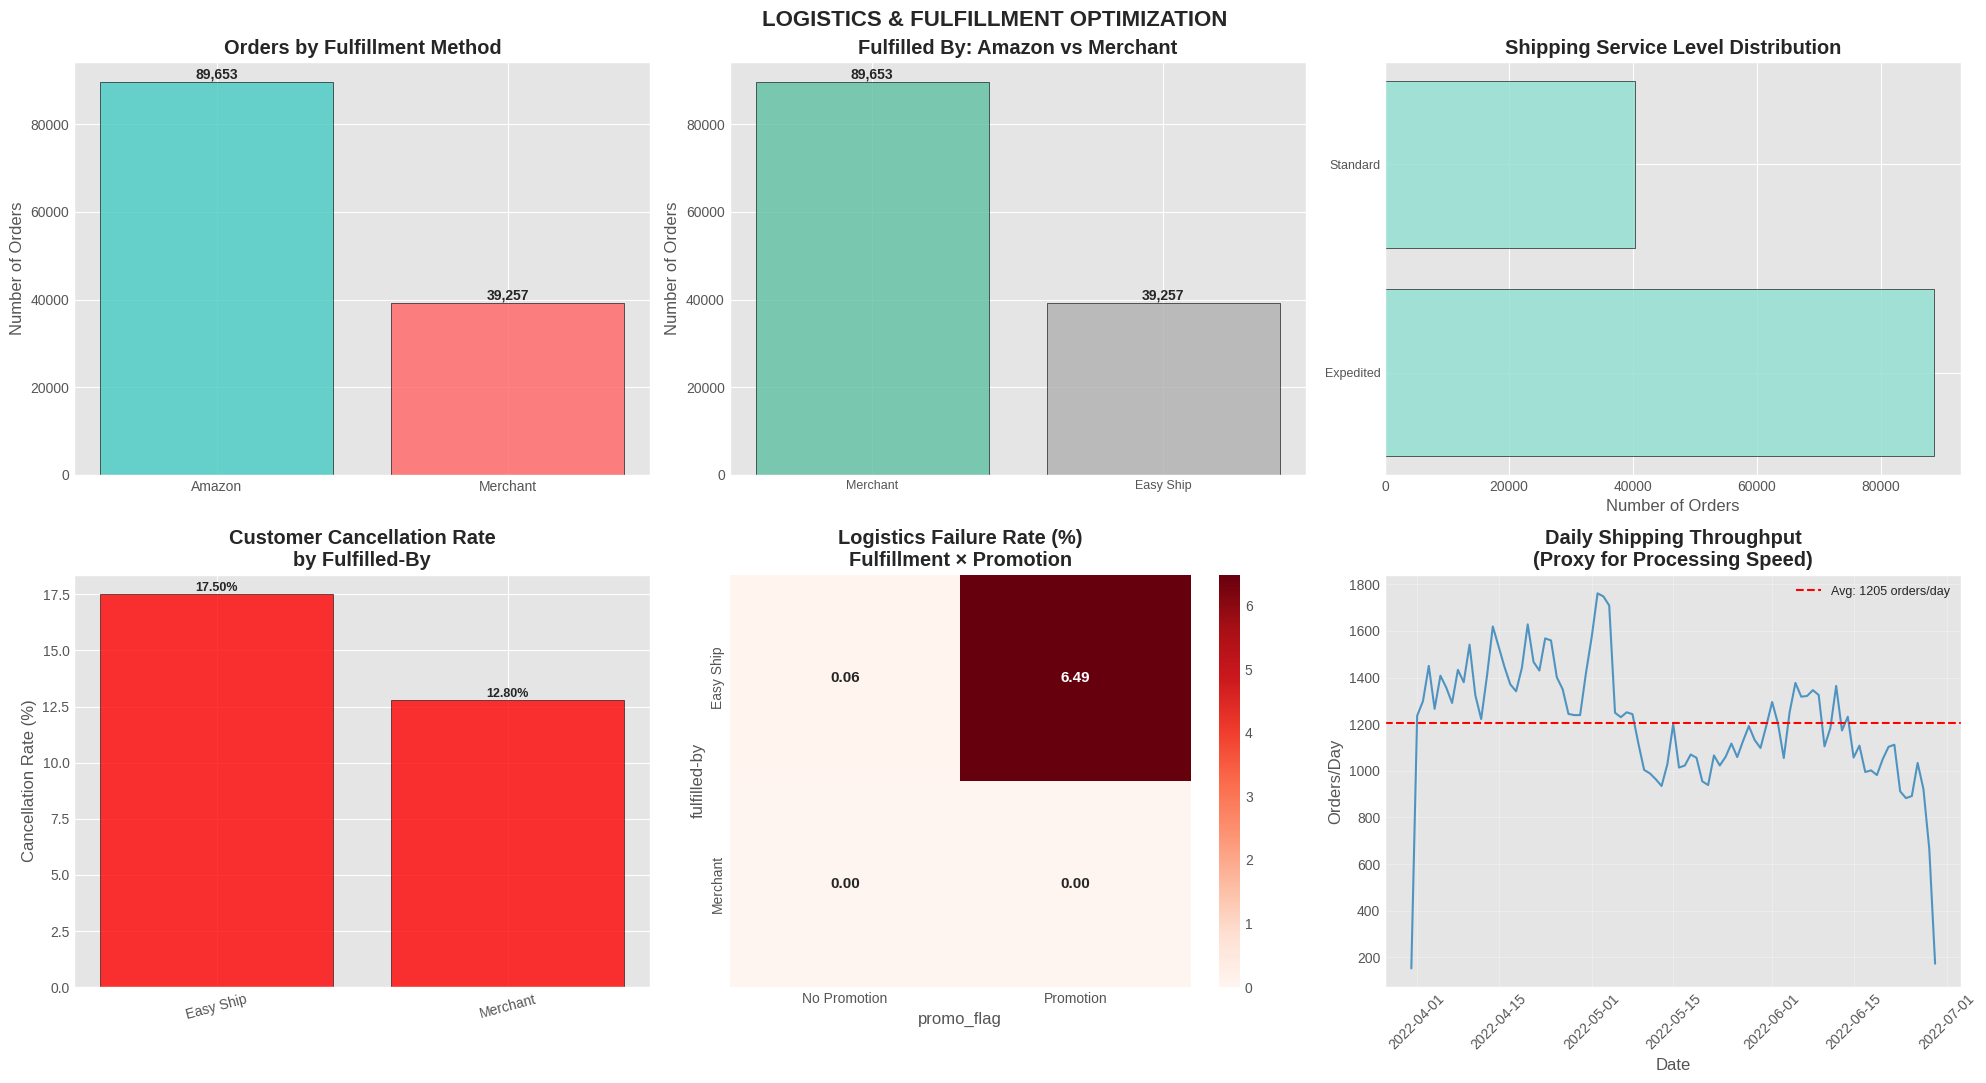

Chart saved: analysis_3_logistics_fulfillment.png


In [115]:
# --- VISUALIZATIONS: Logistics & Fulfillment ---
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
fig.suptitle('LOGISTICS & FULFILLMENT OPTIMIZATION', fontsize=16, fontweight='bold')

# 1. Orders by Fulfillment Method
ax = axes[0, 0]
fc = df1['Fulfilment'].value_counts()
bars_f = ax.bar(fc.index, fc.values, color=['#4ECDC4', '#FF6B6B'], alpha=0.85, edgecolor='black')
ax.set_title('Orders by Fulfillment Method', fontweight='bold')
ax.set_ylabel('Number of Orders')
for bar in bars_f:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontweight='bold')

# 2. Fulfilled By
ax = axes[0, 1]
fbc = df1['fulfilled-by'].value_counts()
colors_fb = plt.cm.Set2(np.linspace(0, 1, len(fbc)))
bars_fb = ax.bar(range(len(fbc)), fbc.values, color=colors_fb, alpha=0.85, edgecolor='black')
ax.set_xticks(range(len(fbc)))
ax.set_xticklabels(fbc.index, fontsize=9)
ax.set_title('Fulfilled By: Amazon vs Merchant', fontweight='bold')
ax.set_ylabel('Number of Orders')
for bar in bars_fb:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontweight='bold')

# 3. Shipping Service Level
ax = axes[0, 2]
svc = df1['ship-service-level'].value_counts()
ax.barh(range(len(svc)), svc.values, color='#95E1D3', alpha=0.85, edgecolor='black')
ax.set_yticks(range(len(svc)))
ax.set_yticklabels(svc.index, fontsize=9)
ax.set_title('Shipping Service Level Distribution', fontweight='bold')
ax.set_xlabel('Number of Orders')

# 4. Cancellation Rate by Fulfilled-By
ax = axes[1, 0]
cfb = df1.groupby('fulfilled-by')['customer_cancelled'].mean().sort_values(ascending=False)
colors_cfb = ['red' if x > 0.1 else 'orange' if x > 0.05 else 'green' for x in cfb.values]
bars_cfb = ax.bar(cfb.index, cfb.values * 100, color=colors_cfb, alpha=0.8, edgecolor='black')
ax.set_title('Customer Cancellation Rate\nby Fulfilled-By', fontweight='bold')
ax.set_ylabel('Cancellation Rate (%)')
ax.tick_params(axis='x', rotation=15)
for bar in bars_cfb:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{bar.get_height():.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=9)

# 5. Logistics Failure Heatmap
ax = axes[1, 1]
sns.heatmap(lf_pivot * 100, annot=True, fmt='.2f', cmap='Reds', ax=ax,
            annot_kws={'fontsize': 11, 'fontweight': 'bold'})
ax.set_title('Logistics Failure Rate (%)\nFulfillment × Promotion', fontweight='bold')

# 6. Daily Shipping Throughput
ax = axes[1, 2]
ax.plot(daily_shipped['Date'], daily_shipped['Orders_Processed'],
        linewidth=1.5, color='#2980b9', alpha=0.8)
ax.axhline(y=avg_daily, color='red', linestyle='--', linewidth=1.5,
           label=f'Avg: {avg_daily:.0f} orders/day')
ax.set_title('Daily Shipping Throughput\n(Proxy for Processing Speed)', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Orders/Day')
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('analysis_3_logistics_fulfillment.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: analysis_3_logistics_fulfillment.png")

# ============================================================
# ANALYSIS 4: PRODUCT MANAGEMENT & INVENTORY OPTIMIZATION
# ============================================================

In [116]:
print("\n" + "=" * 80)
print("ANALYSIS 4: PRODUCT MANAGEMENT & INVENTORY OPTIMIZATION")
print("=" * 80)

# High-demand categories
print("\nHigh-Demand Product Categories:")
category_demand = df1.groupby('Category').agg(
    Orders=('Order ID', 'count'),
    Revenue=('Amount', 'sum'),
    Units_Sold=('Qty', 'sum'),
    Cancel_Rate=('customer_cancelled', 'mean'),
    Logistics_Fail_Rate=('logistics_failed', 'mean')
).sort_values('Revenue', ascending=False)
print(category_demand.head(10))


ANALYSIS 4: PRODUCT MANAGEMENT & INVENTORY OPTIMIZATION

High-Demand Product Categories:
               Orders      Revenue  Units_Sold  Cancel_Rate  \
Category                                                      
Set             50260  35768537.14       45275     0.146080   
kurta           49846  19467296.48       45034     0.145508   
Western Dress   15494  10207670.00       13942     0.137214   
Top             10619   4907932.00        9900     0.120350   
Ethnic Dress     1158    732061.00        1052     0.126079   
Blouse            926    420569.00         864     0.125270   
Bottom            440    135998.00         398     0.136364   
Saree             164    114694.00         152     0.128049   
Dupatta             3       915.00           3     0.000000   

               Logistics_Fail_Rate  
Category                            
Set                       0.016693  
kurta                     0.015066  
Western Dress             0.022202  
Top                       0.012

In [117]:
# Quantity analysis
print(f"\nAverage Quantity per Order  : {df1['Qty'].mean():.2f}")
print(f"Median Quantity per Order   : {df1['Qty'].median():.0f}")
print(f"Max Quantity in Single Order: {int(df1['Qty'].max())}")
print(f"Total Units Sold            : {int(df1['Qty'].sum()):,}")


Average Quantity per Order  : 0.90
Median Quantity per Order   : 1
Max Quantity in Single Order: 15
Total Units Sold            : 116,620


In [118]:
# Size analysis
print("\nTop 10 Sizes by Orders:")
size_analysis = df1.groupby('Size').agg(
    Orders=('Order ID', 'count'),
    Units_Sold=('Qty', 'sum'),
    Cancel_Rate=('customer_cancelled', 'mean')
).sort_values('Orders', ascending=False).head(10)
print(size_analysis)


Top 10 Sizes by Orders:
      Orders  Units_Sold  Cancel_Rate
Size                                 
M      22696       20444     0.148705
L      22113       19984     0.142134
XL     20874       18925     0.136773
XXL    18086       16508     0.133750
S      17086       15333     0.151703
3XL    14809       13524     0.126072
XS     11156        9938     0.167354
6XL      737         688     0.097693
5XL      550         513     0.100000
4XL      424         395     0.113208


In [119]:
# ABC Inventory Classification
print("\nABC Inventory Classification (80-20 Rule):")
cat_rev = df1.groupby('Category')['Amount'].sum().sort_values(ascending=False)
cum_pct = (cat_rev.cumsum() / cat_rev.sum()) * 100
a_cats = cum_pct[cum_pct <= 80].index.tolist()
b_cats = cum_pct[(cum_pct > 80) & (cum_pct <= 95)].index.tolist()
c_cats = cum_pct[cum_pct > 95].index.tolist()
print(f"  A-Class (Top 80% revenue) : {len(a_cats)} categories → {', '.join(a_cats[:5])}")
print(f"  B-Class (80–95% revenue)  : {len(b_cats)} categories → {', '.join(b_cats[:3])}")
print(f"  C-Class (95–100% revenue) : {len(c_cats)} categories")



ABC Inventory Classification (80-20 Rule):
  A-Class (Top 80% revenue) : 2 categories → Set, kurta
  B-Class (80–95% revenue)  : 1 categories → Western Dress
  C-Class (95–100% revenue) : 6 categories


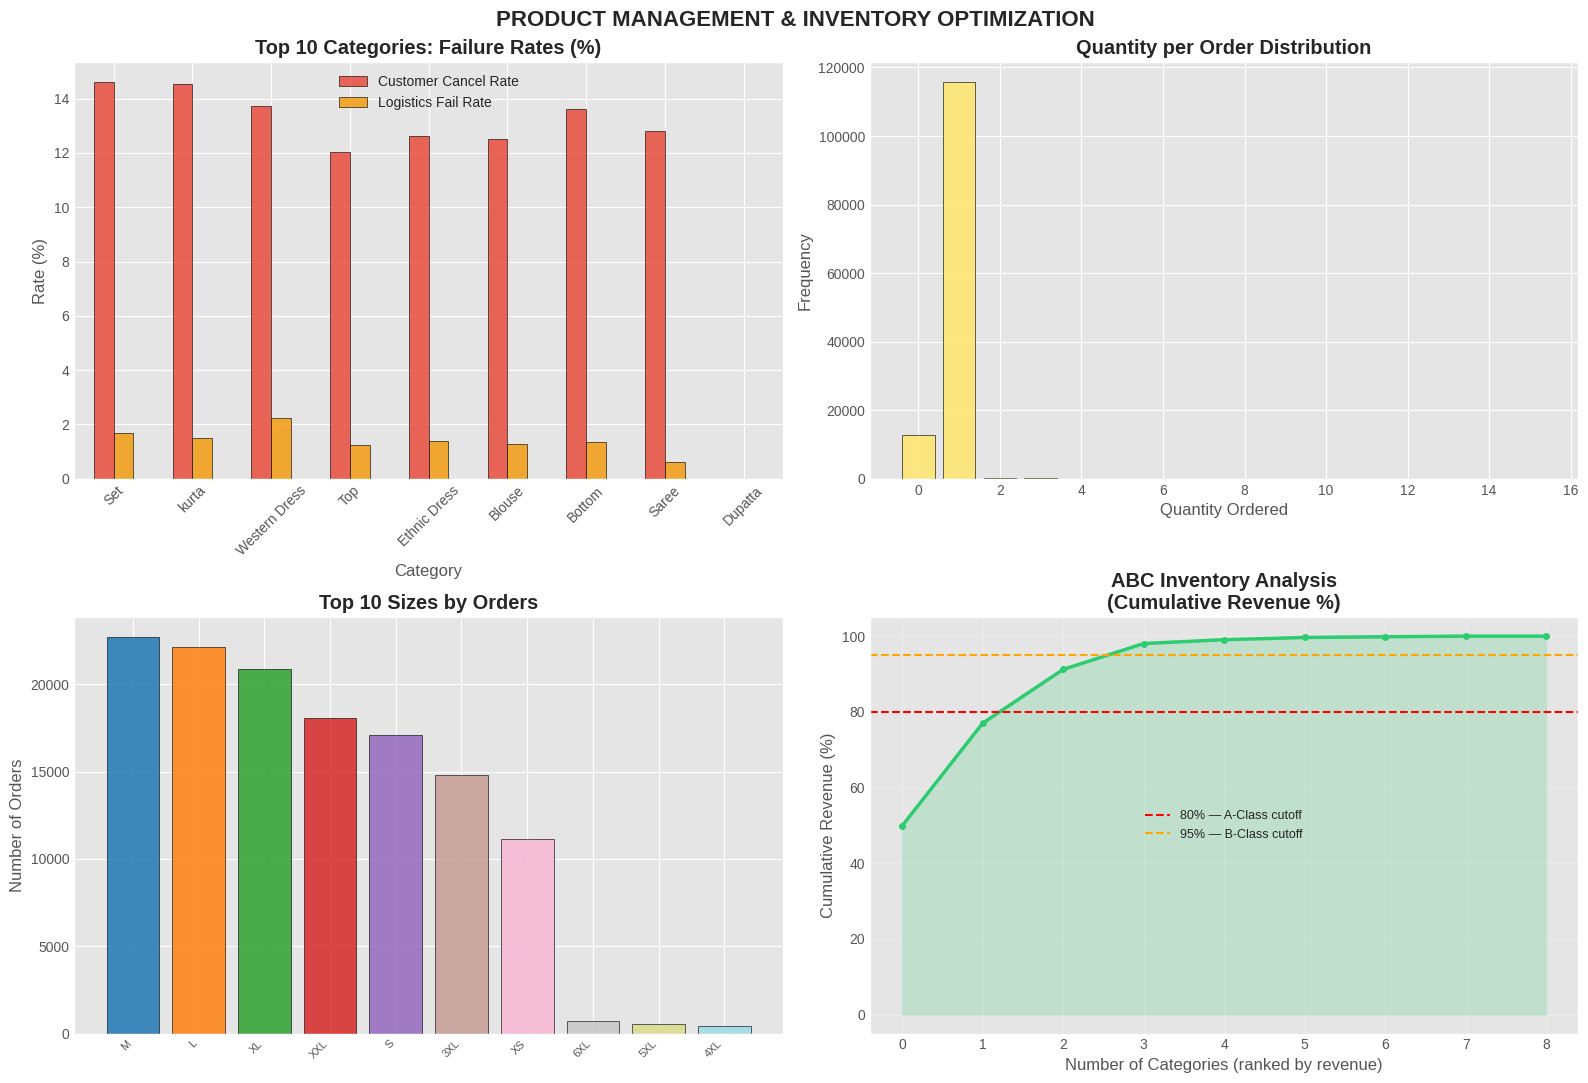

Chart saved: analysis_4_product_management.png


In [120]:
# --- VISUALIZATIONS: Product Management ---
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('PRODUCT MANAGEMENT & INVENTORY OPTIMIZATION', fontsize=16, fontweight='bold')

# 1. Top 10 Categories — Failure Rates
ax = axes[0, 0]
top10_cats = category_demand.head(10)[['Cancel_Rate', 'Logistics_Fail_Rate']] * 100
top10_cats.plot(kind='bar', ax=ax, color=['#e74c3c', '#f39c12'], alpha=0.85, edgecolor='black')
ax.set_title('Top 10 Categories: Failure Rates (%)', fontweight='bold')
ax.set_ylabel('Rate (%)')
ax.tick_params(axis='x', rotation=45)
ax.legend(['Customer Cancel Rate', 'Logistics Fail Rate'])

# 2. Quantity per Order Distribution
ax = axes[0, 1]
qty_dist = df1['Qty'].value_counts().sort_index().head(10)
ax.bar(qty_dist.index, qty_dist.values, color='#FFE66D', alpha=0.85, edgecolor='black')
ax.set_title('Quantity per Order Distribution', fontweight='bold')
ax.set_xlabel('Quantity Ordered')
ax.set_ylabel('Frequency')

# 3. Top 10 Sizes by Orders
ax = axes[1, 0]
top_sizes = df1['Size'].value_counts().head(10)
colors_sz = plt.cm.tab20(np.linspace(0, 1, len(top_sizes)))
ax.bar(range(len(top_sizes)), top_sizes.values, color=colors_sz, alpha=0.85, edgecolor='black')
ax.set_xticks(range(len(top_sizes)))
ax.set_xticklabels(top_sizes.index, rotation=45, ha='right', fontsize=8)
ax.set_title('Top 10 Sizes by Orders', fontweight='bold')
ax.set_ylabel('Number of Orders')

# 4. ABC Analysis — Cumulative Revenue %
ax = axes[1, 1]
ax.plot(range(len(cum_pct)), cum_pct.values, color='#2ecc71', linewidth=2.5, marker='o', markersize=4)
ax.axhline(y=80, color='red',    linestyle='--', linewidth=1.5, label='80% — A-Class cutoff')
ax.axhline(y=95, color='orange', linestyle='--', linewidth=1.5, label='95% — B-Class cutoff')
ax.fill_between(range(len(cum_pct)), cum_pct.values, alpha=0.2, color='#2ecc71')
ax.set_title('ABC Inventory Analysis\n(Cumulative Revenue %)', fontweight='bold')
ax.set_xlabel('Number of Categories (ranked by revenue)')
ax.set_ylabel('Cumulative Revenue (%)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('analysis_4_product_management.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: analysis_4_product_management.png")

# ============================================================
# ANALYSIS 5: CUSTOMER SATISFACTION & RETURNS
# ============================================================

In [121]:
print("\n" + "=" * 80)
print("ANALYSIS 5: CUSTOMER SATISFACTION & RETURNS")
print("=" * 80)

total_log_failed = df1['logistics_failed'].sum()
print(f"\nCustomer Cancellations  : {int(df1['customer_cancelled'].sum())} ({df1['customer_cancelled'].mean()*100:.2f}%)")
print(f"Logistics Failures      : {int(total_log_failed)} ({total_log_failed/total_orders*100:.2f}%)")
print(f"Revenue Lost (Customer) : ₹{df1[df1['customer_cancelled']]['Amount'].sum():,.2f}")
print(f"Revenue Lost (Logistics): ₹{df1[df1['logistics_failed']]['Amount'].sum():,.2f}")


ANALYSIS 5: CUSTOMER SATISFACTION & RETURNS

Customer Cancellations  : 18342 (14.23%)
Logistics Failures      : 2101 (1.63%)
Revenue Lost (Customer) : ₹7,295.00
Revenue Lost (Logistics): ₹1,380,403.00


In [122]:
# Cancellation by category
print("\nCancellation Rate by Category (Top 10):")
cat_cancel = df1.groupby('Category').apply(
    lambda x: pd.Series({
        'Total_Orders': len(x),
        'Cancelled': int(x['customer_cancelled'].sum()),
        'Cancel_Rate_%': x['customer_cancelled'].mean() * 100,
        'Revenue_Lost': x[x['customer_cancelled']]['Amount'].sum()
    })
).sort_values('Cancel_Rate_%', ascending=False).head(10)
print(cat_cancel)


Cancellation Rate by Category (Top 10):
               Total_Orders  Cancelled  Cancel_Rate_%  Revenue_Lost
Category                                                           
Set                 50260.0     7342.0      14.608038        4492.0
kurta               49846.0     7253.0      14.550817        1089.0
Western Dress       15494.0     2126.0      13.721441         899.0
Bottom                440.0       60.0      13.636364           0.0
Saree                 164.0       21.0      12.804878           0.0
Ethnic Dress         1158.0      146.0      12.607945           0.0
Blouse                926.0      116.0      12.526998           0.0
Top                 10619.0     1278.0      12.035032         815.0
Dupatta                 3.0        0.0       0.000000           0.0


In [123]:
# Problematic SKUs
print("\nProblematic SKUs (≥10 orders, >20% cancel rate):")
sku_cancel = df1.groupby('SKU').apply(
    lambda x: pd.Series({
        'Total_Orders': len(x),
        'Cancelled': int(x['customer_cancelled'].sum()),
        'Cancel_Rate_%': x['customer_cancelled'].mean() * 100,
        'Revenue_Lost': x[x['customer_cancelled']]['Amount'].sum()
    })
)
problematic = sku_cancel[
    (sku_cancel['Total_Orders'] >= 10) & (sku_cancel['Cancel_Rate_%'] > 20)
].sort_values('Cancel_Rate_%', ascending=False).head(10)
print(problematic)


Problematic SKUs (≥10 orders, >20% cancel rate):
                   Total_Orders  Cancelled  Cancel_Rate_%  Revenue_Lost
SKU                                                                    
SET409-KR-NP-M             11.0        7.0      63.636364           0.0
JNE3608-KR-L               32.0       19.0      59.375000           0.0
JNE3734-KR-XL              12.0        7.0      58.333333           0.0
J0159-DR-XXL               10.0        5.0      50.000000           0.0
J0352-KR-M                 10.0        5.0      50.000000           0.0
SET230-KR-PP-XS            12.0        6.0      50.000000           0.0
SET195-KR-NP-A-XL          10.0        5.0      50.000000           0.0
JNE3407-KR-XXL             16.0        8.0      50.000000           0.0
SET375-KR-NP-M             35.0       17.0      48.571429           0.0
JNE3751-KR-XS              15.0        7.0      46.666667           0.0


In [124]:
# Delivery performance
delivered = df1[df1['Status'].str.contains('Delivered', case=False, na=False)]
shipped   = df1[df1['Status'].str.contains('Shipped',   case=False, na=False)]
pending   = df1[df1['Status'].str.contains('Pending',   case=False, na=False)]
print(f"\nDelivered : {len(delivered)} ({len(delivered)/total_orders*100:.2f}%)")
print(f"Shipped   : {len(shipped)} ({len(shipped)/total_orders*100:.2f}%)")
print(f"Pending   : {len(pending)} ({len(pending)/total_orders*100:.2f}%)")


Delivered : 28764 (22.31%)
Shipped   : 109632 (85.05%)
Pending   : 939 (0.73%)


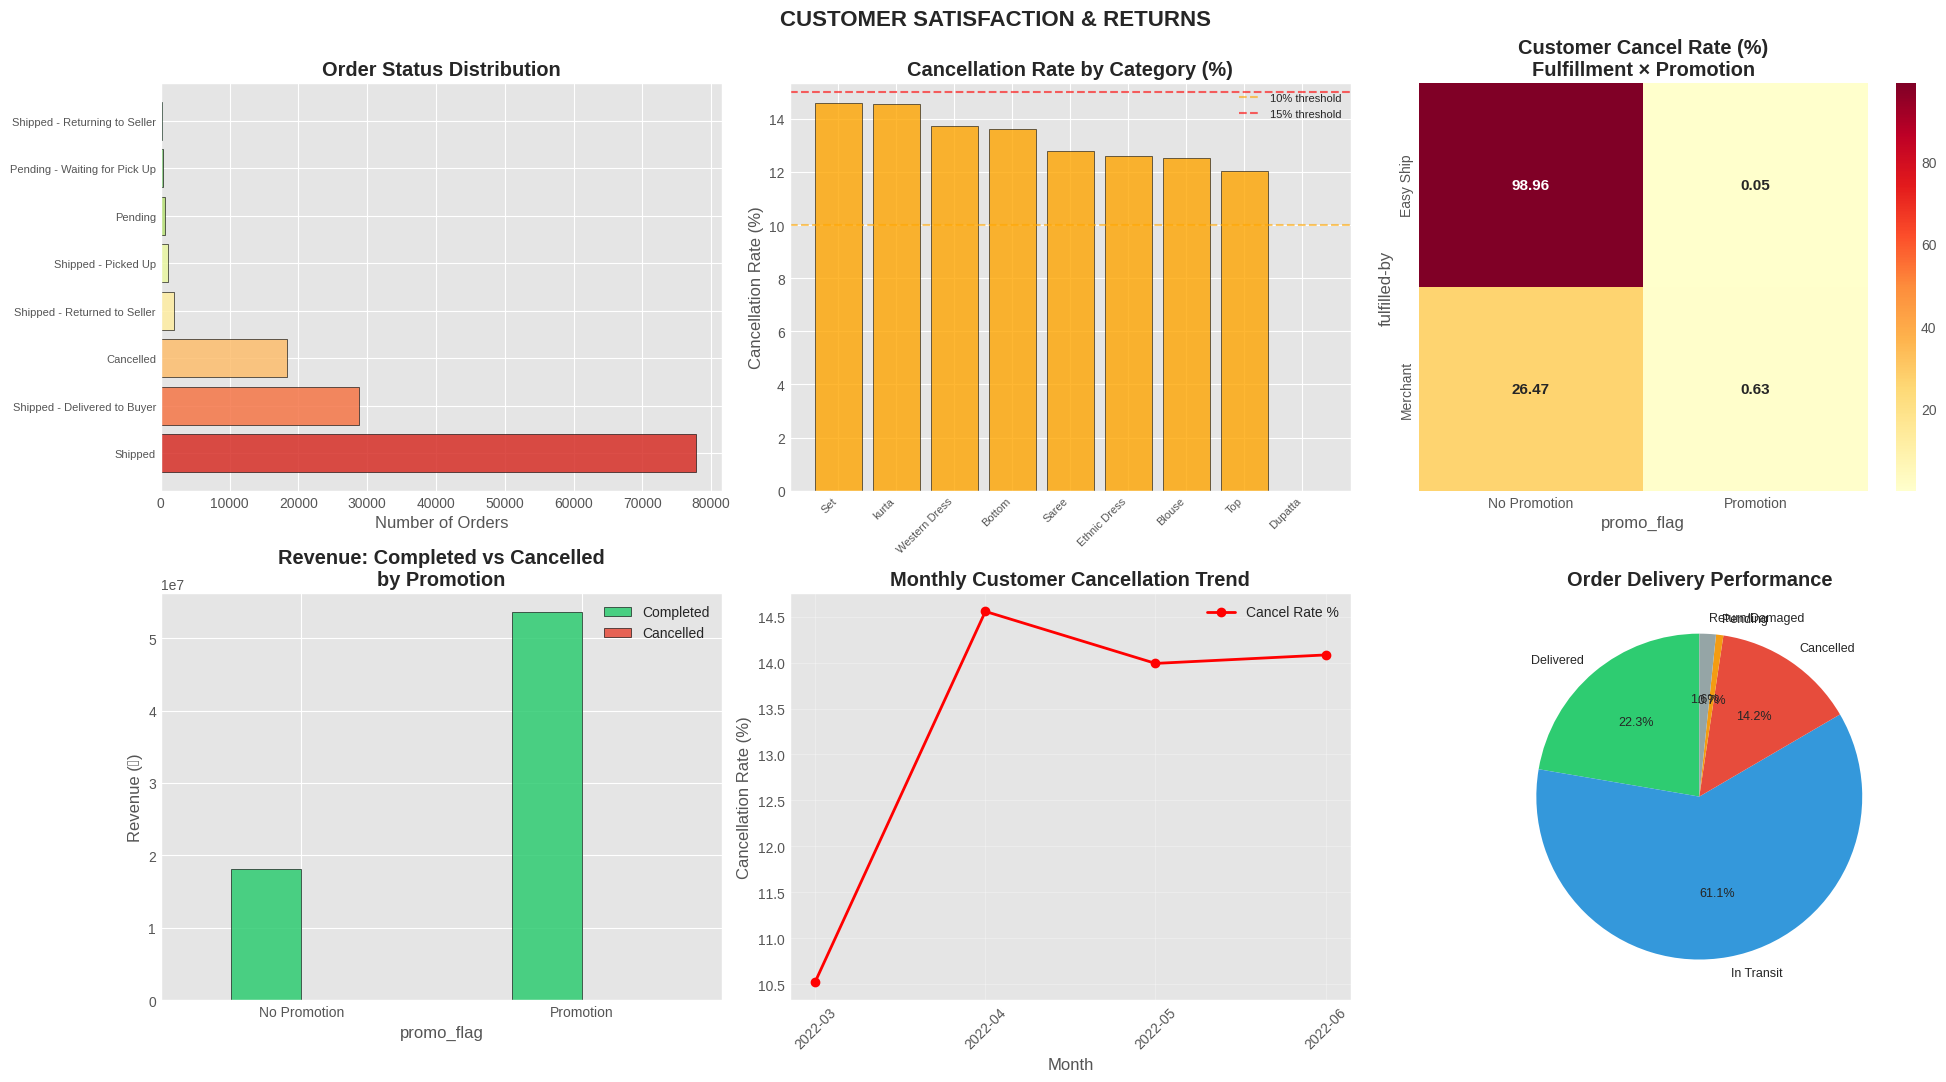

Chart saved: analysis_5_customer_satisfaction.png


In [125]:
# --- VISUALIZATIONS: Customer Satisfaction ---
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
fig.suptitle('CUSTOMER SATISFACTION & RETURNS', fontsize=16, fontweight='bold')

# 1. Order Status Distribution
ax = axes[0, 0]
sc = df1['Status'].value_counts().head(8)
colors_st = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(sc)))
ax.barh(range(len(sc)), sc.values, color=colors_st, alpha=0.85, edgecolor='black')
ax.set_yticks(range(len(sc)))
ax.set_yticklabels(sc.index, fontsize=8)
ax.set_title('Order Status Distribution', fontweight='bold')
ax.set_xlabel('Number of Orders')

# 2. Cancellation Rate by Category
ax = axes[0, 1]
ccp = df1.groupby('Category')['customer_cancelled'].mean().sort_values(ascending=False).head(10) * 100
colors_cc2 = ['red' if x > 15 else 'orange' if x > 10 else 'green' for x in ccp.values]
ax.bar(range(len(ccp)), ccp.values, color=colors_cc2, alpha=0.8, edgecolor='black')
ax.set_xticks(range(len(ccp)))
ax.set_xticklabels(ccp.index, rotation=45, ha='right', fontsize=8)
ax.set_title('Cancellation Rate by Category (%)', fontweight='bold')
ax.set_ylabel('Cancellation Rate (%)')
ax.axhline(y=10, color='orange', linestyle='--', alpha=0.6, label='10% threshold')
ax.axhline(y=15, color='red',    linestyle='--', alpha=0.6, label='15% threshold')
ax.legend(fontsize=8)

# 3. Customer Cancellation Heatmap
ax = axes[0, 2]
sns.heatmap(cc_pivot * 100, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax,
            annot_kws={'fontsize': 11, 'fontweight': 'bold'})
ax.set_title('Customer Cancel Rate (%)\nFulfillment × Promotion', fontweight='bold')

# 4. Revenue Lost vs Completed by Promotion
ax = axes[1, 0]
rpc = df1.groupby(['promo_flag', 'customer_cancelled'])['Amount'].sum().unstack()
rpc.columns = ['Completed', 'Cancelled']
rpc.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'], alpha=0.85, edgecolor='black')
ax.set_title('Revenue: Completed vs Cancelled\nby Promotion', fontweight='bold')
ax.set_ylabel('Revenue (₹)')
ax.tick_params(axis='x', rotation=0)
ax.legend(['Completed', 'Cancelled'])

# 5. Monthly Cancellation Trend
ax = axes[1, 1]
ax.plot(cancel_trend.index.astype(str), cancel_trend['cancel_rate'] * 100,
        marker='o', color='red', linewidth=2, label='Cancel Rate %')
ax.set_title('Monthly Customer Cancellation Trend', fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Cancellation Rate (%)')
ax.tick_params(axis='x', rotation=45)
ax.grid(alpha=0.3)
ax.legend()

# 6. Delivery Performance Pie
ax = axes[1, 2]
status_groups = {
    'Delivered'       : df1['Status'].str.contains('Delivered', case=False, na=False).sum(),
    'In Transit'      : (df1['Status'].str.startswith('Shipped', na=False) &
                         ~df1['Status'].str.contains('Delivered|Return|Reject|Lost|Damaged', na=False)).sum(),
    'Cancelled'       : (df1['Status'] == 'Cancelled').sum(),
    'Pending'         : df1['Status'].str.contains('Pending', case=False, na=False).sum(),
    'Return/Damaged'  : df1['Status'].str.contains('Return|Damaged|Lost|Rejected', case=False, na=False).sum(),
}
status_groups = {k: v for k, v in status_groups.items() if v > 0}
ax.pie(list(status_groups.values()), labels=list(status_groups.keys()),
       autopct='%1.1f%%', colors=['#2ecc71','#3498db','#e74c3c','#f39c12','#95a5a6'],
       startangle=90, textprops={'fontsize': 9})
ax.set_title('Order Delivery Performance', fontweight='bold')

plt.tight_layout()
plt.savefig('analysis_5_customer_satisfaction.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: analysis_5_customer_satisfaction.png")

# ============================================================
# ADVANCED EDA
# ============================================================


In [126]:
print("" + "=" * 80)
print("ADVANCED EDA")
print("=" * 80)

# Correlation Analysis: Quantity vs Amount
print("Correlation Analysis (Qty vs Amount):")
corr_val = df1[['Qty', 'Amount']].corr()
print(corr_val)
print(f"  Pearson correlation between Qty and Amount: {df1['Qty'].corr(df1['Amount']):.4f}")

ADVANCED EDA
Correlation Analysis (Qty vs Amount):
             Qty    Amount
Qty     1.000000  0.528837
Amount  0.528837  1.000000
  Pearson correlation between Qty and Amount: 0.5288


In [127]:
# Promotion Effectiveness
print("Promotion Effectiveness:")
promo_eff = df1.groupby('promo_flag').agg(
    Orders=('Order ID', 'count'),
    Revenue=('Amount', 'sum'),
    AOV=('Amount', 'mean'),
    Avg_Qty=('Qty', 'mean'),
    Cancel_Rate=('customer_cancelled', 'mean')
)
promo_eff['Revenue_%'] = promo_eff['Revenue'] / promo_eff['Revenue'].sum() * 100
print(promo_eff)

Promotion Effectiveness:
              Orders      Revenue         AOV   Avg_Qty  Cancel_Rate  \
promo_flag                                                             
No Promotion   49131  18182499.62  370.082018  0.748855     0.366876   
Promotion      79779  53573173.00  671.519736  1.000614     0.003973   

              Revenue_%  
promo_flag               
No Promotion   25.33946  
Promotion      74.66054  


In [128]:
# Revenue by Service Level
print("Revenue by Shipping Service Level:")
svc_rev = df1.groupby('ship-service-level').agg(
    Revenue=('Amount', 'sum'),
    Orders=('Order ID', 'count'),
    AOV=('Amount', 'mean')
)
print(svc_rev)

Revenue by Shipping Service Level:
                        Revenue  Orders         AOV
ship-service-level                                 
Expedited           50578613.00   88570  571.058067
Standard            21177059.62   40340  524.964294


In [129]:
# Revenue by Size
print("Revenue by Size (Top 10):")
size_rev = df1.groupby('Size').agg(
    Revenue=('Amount', 'sum'),
    Orders=('Order ID', 'count')
).sort_values('Revenue', ascending=False).head(10)
print(size_rev)

Revenue by Size (Top 10):
          Revenue  Orders
Size                     
M     12626582.57   22696
L     12072708.00   22113
XL    11387975.00   20874
XXL    9779828.00   18086
S      9664979.57   17086
3XL    8440932.00   14809
XS     6340608.48   11156
6XL     543699.00     737
5XL     400284.00     550
4XL     307374.00     424


In [131]:
print("\nCancellation Rate by State (Top 10):")
state_cancel = df1.groupby('ship-state').apply(
    lambda x: pd.Series({
        'Total_Orders': len(x),
        'Cancelled': x['customer_cancelled'].sum(),
        'Cancel_Rate_%': x['customer_cancelled'].mean() * 100
    })
).sort_values('Cancel_Rate_%', ascending=False).head(10)
print(state_cancel)


Cancellation Rate by State (Top 10):
                    Total_Orders  Cancelled  Cancel_Rate_%
ship-state                                                
APO                          1.0        1.0     100.000000
Meghalaya                    3.0        3.0     100.000000
Arunachal Pradesh            3.0        1.0      33.333333
Rajshthan                    3.0        1.0      33.333333
LAKSHADWEEP                  4.0        1.0      25.000000
Odisha                      21.0        5.0      23.809524
MIZORAM                     75.0       14.0      18.666667
HIMACHAL PRADESH           788.0      146.0      18.527919
KERALA                    6584.0     1174.0      17.831106
ANDAMAN & NICOBAR          257.0       45.0      17.509728


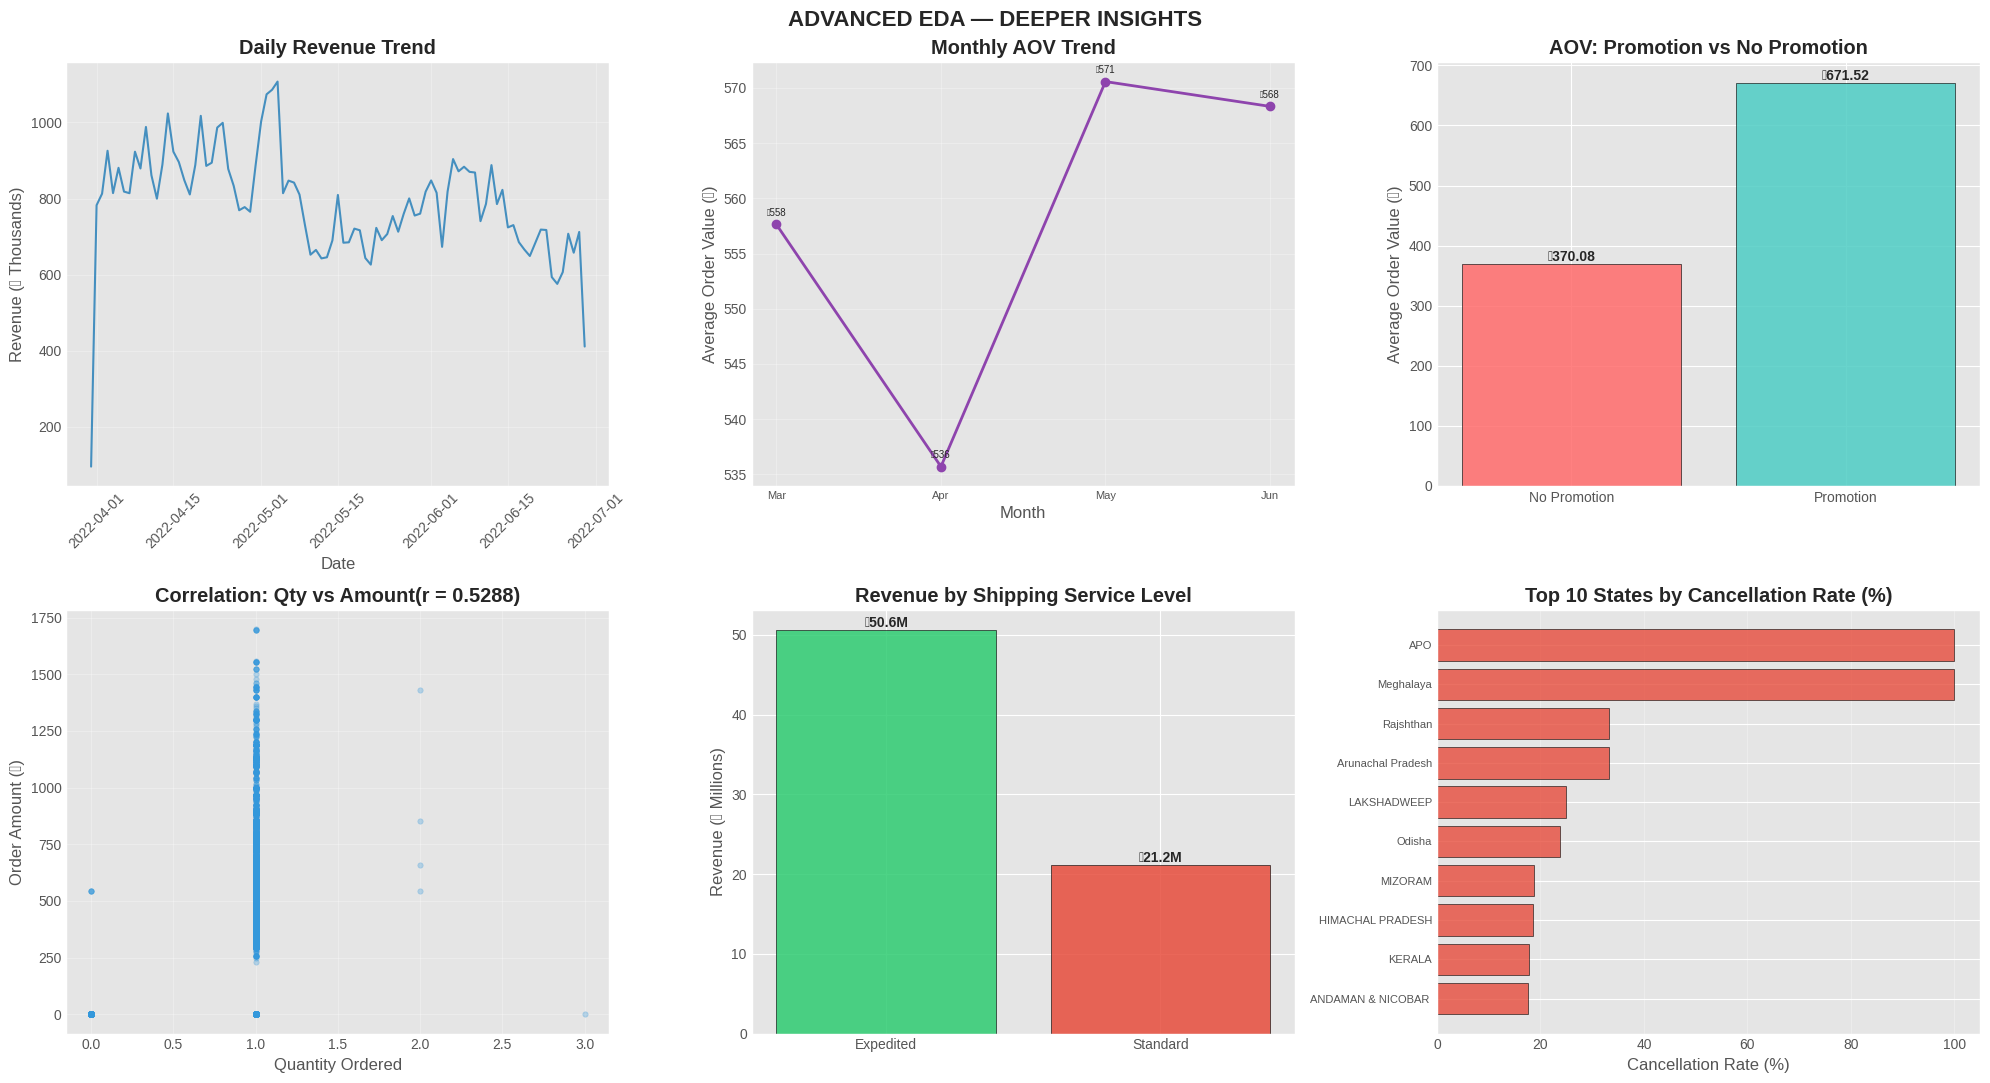

Chart saved: analysis_6_advanced_eda.png


In [132]:
# --- VISUALIZATIONS: Advanced EDA ---
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
fig.suptitle('ADVANCED EDA — DEEPER INSIGHTS', fontsize=16, fontweight='bold')

# 1. Daily Revenue Trend (line chart)
ax = axes[0, 0]
ax.plot(daily_revenue['Date'], daily_revenue['Revenue'] / 1000,
        linewidth=1.5, color='#2980b9', alpha=0.85)
ax.set_title('Daily Revenue Trend', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Revenue (₹ Thousands)')
ax.tick_params(axis='x', rotation=45)
ax.grid(alpha=0.3)

# 2. Monthly AOV Trend
ax = axes[0, 1]
ax.plot(range(len(monthly_aov)), monthly_aov['AOV'],
        marker='o', linewidth=2, color='#8e44ad', markersize=6)
ax.set_title('Monthly AOV Trend', fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Average Order Value (₹)')
ax.set_xticks(range(len(monthly_aov)))
ax.set_xticklabels([f"{r['MonthName'][:3]}" for _, r in monthly_aov.iterrows()], fontsize=8)
ax.grid(alpha=0.3)
for i, row in monthly_aov.iterrows():
    ax.annotate(f"₹{row['AOV']:.0f}",
                xy=(list(monthly_aov.index).index(i), row['AOV']),
                xytext=(0, 6), textcoords='offset points',
                ha='center', fontsize=7)

# 3. Promotion AOV Comparison
ax = axes[0, 2]
promo_aov = df1.groupby('promo_flag')['Amount'].mean()
colors_pa = ['#FF6B6B', '#4ECDC4']
bars_pa = ax.bar(promo_aov.index, promo_aov.values,
                 color=colors_pa, alpha=0.85, edgecolor='black')
ax.set_title('AOV: Promotion vs No Promotion', fontweight='bold')
ax.set_ylabel('Average Order Value (₹)')
for bar in bars_pa:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'₹{bar.get_height():.2f}', ha='center', va='bottom', fontweight='bold')

# 4. Correlation Scatter: Qty vs Amount
ax = axes[1, 0]
sample = df1.sample(min(3000, len(df1)), random_state=42)
ax.scatter(sample['Qty'], sample['Amount'], alpha=0.3, color='#3498db', s=15)
ax.set_title(f'Correlation: Qty vs Amount(r = {df1["Qty"].corr(df1["Amount"]):.4f})',
             fontweight='bold')
ax.set_xlabel('Quantity Ordered')
ax.set_ylabel('Order Amount (₹)')
ax.grid(alpha=0.3)

# 5. Revenue by Service Level
ax = axes[1, 1]
svc_rev_plot = df1.groupby('ship-service-level')['Amount'].sum().sort_values(ascending=False)
bars_svc = ax.bar(svc_rev_plot.index, svc_rev_plot.values / 1e6,
                  color=['#2ecc71', '#e74c3c', '#3498db'][:len(svc_rev_plot)],
                  alpha=0.85, edgecolor='black')
ax.set_title('Revenue by Shipping Service Level', fontweight='bold')
ax.set_ylabel('Revenue (₹ Millions)')
for bar in bars_svc:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'₹{bar.get_height():.1f}M', ha='center', va='bottom', fontweight='bold')

# 6. Cancellation by State (Top 10)
ax = axes[1, 2]
state_cancel_plot = state_cancel['Cancel_Rate_%'].sort_values(ascending=True)
ax.barh(range(len(state_cancel_plot)), state_cancel_plot.values,
        color='#e74c3c', alpha=0.8, edgecolor='black')
ax.set_yticks(range(len(state_cancel_plot)))
ax.set_yticklabels(state_cancel_plot.index, fontsize=8)
ax.set_title('Top 10 States by Cancellation Rate (%)', fontweight='bold')
ax.set_xlabel('Cancellation Rate (%)')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('analysis_6_advanced_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: analysis_6_advanced_eda.png")

# ============================================================
# SUMMARY & RECOMMENDATIONS
# ============================================================

In [133]:
print("\n" + "=" * 80)
print("SUMMARY OF KEY INSIGHTS")
print("=" * 80)
print("""
1. PROMOTIONS are the strongest driver of revenue AND order stability.
   - Promotional orders contribute the majority of total revenue.
   - They show significantly lower customer cancellation rates.
   - Key offer types (free shipping, financing) reduce purchase friction.

2. FULFILLMENT METHOD is a critical operational risk.
   - Easy Ship without promotion shows the highest order failure rates.
   - These failures are logistics-driven, not customer-driven.
   - Promotions substantially mitigate Easy Ship failures.

3. PRODUCT CATEGORY & SIZE are NOT primary risk factors.
   - Cancellation rates are consistent across major categories.
   - High-volume categories appear riskier only due to volume — not higher rates.
   - ABC analysis shows a small set of A-class categories drives 80% of revenue.

4. GEOGRAPHY does not materially drive cancellations.
   - Order outcomes are uniform across major states and cities.
   - Operational issues are systemic, not region-specific.

5. B2B is a high-quality, underutilised segment.
   - Lower cancellation and logistics failure rates.
   - Higher average order value than B2C.
   - Represents a stable and scalable growth opportunity.
""")

print("=" * 80)
print("BUSINESS RECOMMENDATIONS")
print("=" * 80)
print("""
1. Strengthen & strategically expand promotions.
   - Prioritize promotions for Easy Ship orders specifically.
   - Promotions are risk reducers, not just revenue drivers.

2. Re-evaluate Easy Ship fulfillment strategy.
   - Restrict Easy Ship for non-promoted orders.
   - Conduct a focused audit of Easy Ship logistics workflows.

3. Shift focus from product-level fixes to operational improvements.
   - Category and size are NOT root causes — fix fulfillment and shipping.
   - Invest in order commitment incentives and shipping experience.

4. Protect and grow the B2B segment.
   - Tailored pricing, fulfillment SLAs, dedicated account management.
   - B2B customers are more reliable with higher order values.

5. Inventory — focus on A-class categories.
   - Apply ABC findings to prioritise stock for top revenue categories.
   - Avoid overstocking C-class items; use demand-driven replenishment.
""")

print("\nAll 5 analysis charts saved. Analysis complete!")


SUMMARY OF KEY INSIGHTS

1. PROMOTIONS are the strongest driver of revenue AND order stability.
   - Promotional orders contribute the majority of total revenue.
   - They show significantly lower customer cancellation rates.
   - Key offer types (free shipping, financing) reduce purchase friction.
 
2. FULFILLMENT METHOD is a critical operational risk.
   - Easy Ship without promotion shows the highest order failure rates.
   - These failures are logistics-driven, not customer-driven.
   - Promotions substantially mitigate Easy Ship failures.
 
3. PRODUCT CATEGORY & SIZE are NOT primary risk factors.
   - Cancellation rates are consistent across major categories.
   - High-volume categories appear riskier only due to volume — not higher rates.
   - ABC analysis shows a small set of A-class categories drives 80% of revenue.
 
4. GEOGRAPHY does not materially drive cancellations.
   - Order outcomes are uniform across major states and cities.
   - Operational issues are systemic, not r